# BEV Fusion Exploration (Camera + LiDAR)

In [1]:
# Core imports for data loading + plotting.
from __future__ import annotations

import json
import importlib.util
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# Consistent plotting defaults make visual comparisons easier across cells.
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["image.cmap"] = "viridis"

# __file__ is not available in notebooks; discover repo root by walking up.
PROJECT_ROOT = Path.cwd().resolve()
for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (candidate / "src" / "paths.py").exists():
        PROJECT_ROOT = candidate
        break

# Load paths.py from the exact file path to avoid stale/shadowed imports.
paths_file = PROJECT_ROOT / "src" / "paths.py"
spec = importlib.util.spec_from_file_location("project_paths", paths_file)
paths = importlib.util.module_from_spec(spec)
assert spec is not None and spec.loader is not None
spec.loader.exec_module(paths)

ZOD_MOE_DATA = paths.ZOD_MOE_DATA
OUTPUTS_DIR = paths.OUTPUTS_DIR
ORIGINAL_DATA = paths.ZOD_DINO_DATA / "train2017"

print(f"Loaded paths from: {paths_file}")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"ORIGINAL_DATA: {ORIGINAL_DATA}")
print(f"OUTPUTS_DIR: {OUTPUTS_DIR}")

first_frame_dir = ORIGINAL_DATA / "000000"
print(f"first_frame_dir: {first_frame_dir}")




Loaded paths from: /home/edgelab/multimodal-MoE/src/paths.py
PROJECT_ROOT: /home/edgelab/multimodal-MoE
ORIGINAL_DATA: /home/edgelab/zod_dino_data/train2017
OUTPUTS_DIR: /home/edgelab/multimodal-MoE/outputs
first_frame_dir: /home/edgelab/zod_dino_data/train2017/000000


In [2]:
#helpers
def _read_json(path: Path):
    try:
        return json.loads(path.read_text())
    except Exception as e:
        print(f"Could not read JSON: {path}\n{e}")
        return None


def _iso_to_dt(s: str) -> datetime:
    # Z-suffixed timestamp helper.
    # iso format: 2021-01-01T00:00:00.000000Z
    # datetime format: 2021-01-01 00:00:00+00:00
    return datetime.fromisoformat(s.replace("Z", "+00:00"))


def find_keyframe_timestamp(frame_dir: Path, info_dict: dict) -> datetime:
    """
    Find the keyframe timestamp from the info.json file.
    """
    return _iso_to_dt(info_dict["keyframe_time"])


def nearest_lidar_filename(frame_dir: Path) -> str | None:
    """
    Input: Keyframe Directory Path Object
    Output: LiDAR Filename (lidar_velodyne) with timestamp closest to keyframe_time
    We read the info.json file to get the keyframe_time. 
    Instead of using the full LiDAR window ~ 11-12 .npy files, we just use the closest one. 
    """
    info = _read_json(frame_dir / "info.json")
    lidar_dir = frame_dir / "lidar_velodyne"

    if not isinstance(info, dict) or "keyframe_time" not in info or not lidar_dir.exists():
        return None

    keyframe_timestamp = _iso_to_dt(info["keyframe_time"])
    best_name = None
    # initialize best absolute delta time to infinity
    best_abs_dt = float("inf")

    for p in lidar_dir.glob("*.npy"):
        # Filename pattern: <frame_id>_<car>_<ISO8601>.npy
        timestamp_str = p.stem.rsplit("_", 1)[-1]
        try:
            delta_time_s = (_iso_to_dt(timestamp_str) - keyframe_timestamp).total_seconds()
        except Exception:
            continue

        abs_dt = abs(delta_time_s)
        if abs_dt < best_abs_dt:
            best_abs_dt = abs_dt
            best_name = p.name

    return best_name

nearest_sweep_000000 = nearest_lidar_filename(first_frame_dir)
print("Nearest LiDAR filename for FRAME_DIR:", nearest_sweep_000000)







Nearest LiDAR filename for FRAME_DIR: 000000_india_2021-04-19T10:23:10.416676Z.npy


## LiDAR --> temporally + spatially align --> .npy

In [3]:
from zod.data_classes.sensor import LidarData
from zod.data_classes.ego_motion import EgoMotion
from zod.data_classes.calibration import Calibration
#WE WILL USE THIS FUNCTION TO DENOISE THE LIDAR DATA
from zod.utils.compensation import motion_compensate_pointwise
from zod.constants import Lidar
from zod.cli import visualize_lidar
import json
from zod.data_classes.info import Information
from zod.data_classes.frame import ZodFrame
from zod.visualization.lidar_bev import BEVBox
from zod.constants import AnnotationProject, Camera, Lidar, Anonymization
from zod.data_classes.sensor import LidarData

import plotly.graph_objects as go

from zod.visualization.lidar_3d import Viz3D
from zod.visualization.lidar_on_image import (
    get_3d_transform_camera_lidar,
    project_lidar_to_image,
    draw_projection_as_jet_circles,
)
from zod.utils.geometry import transform_points, get_points_in_camera_fov


In [4]:
oxts_h5_path = first_frame_dir / "oxts.hdf5"
calib_json_path = first_frame_dir / "calibration.json"
closest_lidar_path = first_frame_dir / "lidar_velodyne" / nearest_sweep_000000

#.npy point cloud lidar nearest sweep --> LidarData object 
lidar = LidarData.from_npy(closest_lidar_path)                 # uses lidar filename for core time
# oxts.hdf5 file --> goMotion object
ego = EgoMotion.from_oxts_path(oxts_h5_path)           # gives you poses(t)
# calibration.json --> LidarCalibration object
calib = Calibration.from_json_path(calib_json_path).lidars[Lidar.VELODYNE]


In [5]:
def make_zodframe_from_raw(frame_dir: Path) -> ZodFrame:
    """
    Helper to build ZodFrame object from raw folder.
    We need this since we don't have the traditional ZOD SDK structure,
    But still want to use various methods in the ZOD SDK.
    
    INPUTS: info.json, frame_id
    OUTPUT: ZodFrame object
    """
    info_dict = json.loads((frame_dir / "info.json").read_text())
    frame_id = info_dict.get("id", frame_dir.name)
    prefix = f"single_frames/{frame_id}/"

    def fix_path(p):
        if p is None:
            return None
        if p.startswith(prefix):
            return p[len(prefix):]
        if p.startswith("single_frames/"):
            # fallback if id differs in the string
            return p.split("/", 2)[-1]
        return p

    # top-level file paths
    for k in ["calibration_path", "ego_motion_path", "metadata_path", "oxts_path", "vehicle_data_path"]:
        if info_dict.get(k) is not None:
            info_dict[k] = fix_path(info_dict[k])

    # annotation file paths
    for ann in info_dict.get("annotations", {}).values():
        if ann.get("filepath") is not None:
            ann["filepath"] = fix_path(ann["filepath"])

    # camera frame file paths
    for arr in info_dict.get("camera_frames", {}).values():
        for x in arr:
            if x.get("filepath") is not None:
                x["filepath"] = fix_path(x["filepath"])

    # lidar frame file paths
    for arr in info_dict.get("lidar_frames", {}).values():
        for x in arr:
            if x.get("filepath") is not None:
                x["filepath"] = fix_path(x["filepath"])

    info = Information.from_dict(info_dict)
    info.convert_paths_to_absolute(str(frame_dir))
    return ZodFrame(info)

In [6]:
# Compatibility shim for SDK code that still uses np.cast[...]
if not hasattr(np, "cast"):
    class _CastShim:
        def __getitem__(self, dtype):
            return lambda arr: np.asarray(arr, dtype=dtype)
    np.cast = _CastShim()

In [8]:
# Build ZOD frame object from raw folder helper
frame_dir = ORIGINAL_DATA / "000000"
zod_frame = make_zodframe_from_raw(frame_dir)

# Select nearest lidar sweep and load as SDK LidarData object
nearest_name = nearest_lidar_filename(frame_dir)

lidar_data = LidarData.from_npy(frame_dir / "lidar_velodyne" / nearest_name)

# Reuse previously extracted nearest-sweep LiDAR as the raw input for alignment.
raw_lidar = lidar_data

# Reuse SDK objects directly from zod_frame.
ego_motion = zod_frame.ego_motion
calib = zod_frame.calibration

# Front camera keyframe + exact timestamp (defaults to FRONT + BLUR in SDK).
front_camera_frame = zod_frame.get_camera_frame()
front_image = zod_frame.get_image()
camera_timestamp = front_camera_frame.time.timestamp()  # epoch seconds

print(f"Frame id: {zod_frame.info.id}")
print(f"Front image shape: {front_image.shape}")
print(f"Front camera timestamp (epoch sec): {camera_timestamp:.6f}")
print(f"Raw LiDAR points (reused nearest sweep): {raw_lidar.points.shape[0]}")

Frame id: 000000
Front image shape: (2168, 3848, 3)
Front camera timestamp (epoch sec): 1618827790.444124
Raw LiDAR points (reused nearest sweep): 256867


In [9]:
# Temporal + spatial transformations
# Temporal alignment: motion compensate to the camera timestamp.
# Spatial alignment: LiDAR -> camera, keep camera-FOV points, and keep BOTH coordinate versions.

lidar_calib = calib.lidars[Lidar.VELODYNE]
aligned_lidar = motion_compensate_pointwise(
    raw_lidar,
    ego_motion,
    lidar_calib,
    target_timestamp=camera_timestamp,
)

T_lidar_to_cam = get_3d_transform_camera_lidar(calib, lidar=Lidar.VELODYNE, camera=Camera.FRONT)
aligned_points_cam = transform_points(aligned_lidar.points, T_lidar_to_cam.transform)

positive_depth_mask = aligned_points_cam[:, 2] > 0
points_cam_positive = aligned_points_cam[positive_depth_mask]

points_cam_fov, fov_mask_positive = get_points_in_camera_fov(
    calib.cameras[Camera.FRONT].field_of_view,
    points_cam_positive,
)

# Full-index mask (for intensity/timestamps/diode alignment)
fov_mask_full = np.zeros(aligned_points_cam.shape[0], dtype=bool)
fov_mask_full[positive_depth_mask] = fov_mask_positive

# --- Camera-frame outputs (for fusion) ---
fov_points_cam = aligned_points_cam[fov_mask_full]
fov_intensity = aligned_lidar.intensity[fov_mask_full]
fov_points_cam_xyzi = np.hstack(
    [fov_points_cam.astype(np.float32), fov_intensity.astype(np.float32)[:, None]]
)

# --- LiDAR-frame outputs (for BEV / existing Viz3D cells) ---
T_cam_to_lidar = np.linalg.inv(T_lidar_to_cam.transform)
fov_points_lidar = transform_points(fov_points_cam, T_cam_to_lidar)

fov_lidar = aligned_lidar.copy()
fov_lidar.points = fov_points_lidar
fov_lidar.intensity = fov_intensity
fov_lidar.timestamps = aligned_lidar.timestamps[fov_mask_full]
fov_lidar.diode_idx = aligned_lidar.diode_idx[fov_mask_full]

print(f"Aligned LiDAR points: {aligned_lidar.points.shape[0]}")
print(f"Positive-depth points: {points_cam_positive.shape[0]}")
print(f"FOV points (camera frame): {fov_points_cam.shape[0]}")
print(f"FOV points (LiDAR frame): {fov_lidar.points.shape[0]}")
print(f"FOV XYZI tensor (camera frame): {fov_points_cam_xyzi.shape}")

Aligned LiDAR points: 256867
Positive-depth points: 120340
FOV points (camera frame): 81286
FOV points (LiDAR frame): 81286
FOV XYZI tensor (camera frame): (81286, 4)


In [10]:
# Raw vs aligned in one plot + shift vectors (2 plots)

rng = np.random.default_rng(0)

def _sample_idx(n, max_points=120_000):
    if n <= max_points:
        return np.arange(n)
    return rng.choice(n, size=max_points, replace=False)

# ---------- Figure 1: dense point-cloud overlay ----------
raw_idx = _sample_idx(raw_lidar.points.shape[0], max_points=100_000)
aligned_idx = _sample_idx(aligned_lidar.points.shape[0], max_points=100_000)

viz_shift = Viz3D()

viz_shift.fig.add_trace(
    go.Scatter3d(
        x=raw_lidar.points[raw_idx, 0],
        y=raw_lidar.points[raw_idx, 1],
        z=raw_lidar.points[raw_idx, 2],
        mode="markers",
        name="Raw LiDAR",
        marker=dict(size=1, color="red", opacity=0.30),
    )
)

viz_shift.fig.add_trace(
    go.Scatter3d(
        x=aligned_lidar.points[aligned_idx, 0],
        y=aligned_lidar.points[aligned_idx, 1],
        z=aligned_lidar.points[aligned_idx, 2],
        mode="markers",
        name="Motion-compensated LiDAR",
        marker=dict(size=1, color="deepskyblue", opacity=0.65),
    )
)

viz_shift.fig.update_layout(
    title="Un-skewing: raw (red) vs motion-compensated (blue)",
    scene=dict(
        aspectmode="data",
        xaxis=dict(title="x (m)", range=[-60, 60]),
        yaxis=dict(title="y (m)", range=[-60, 60]),
        zaxis=dict(title="z (m)", range=[-5, 5]),
        camera=dict(
            projection=dict(type="orthographic"),
            eye=dict(x=0.0, y=0.0, z=2.8),
            up=dict(x=0.0, y=1.0, z=0.0),
        ),
    ),
    legend=dict(x=0.01, y=0.99),
)

viz_shift.fig.show()


# ---------- Figure 2: vectors only, differences between raw and aligned LiDAR points ----------
SHOW_VECTOR_FIG = True
if SHOW_VECTOR_FIG:
    k = min(1200, raw_lidar.points.shape[0], aligned_lidar.points.shape[0])  # small for clarity
    idx_line = rng.choice(min(raw_lidar.points.shape[0], aligned_lidar.points.shape[0]), size=k, replace=False)

    x_line = np.stack(
        [raw_lidar.points[idx_line, 0], aligned_lidar.points[idx_line, 0], np.full(k, np.nan)],
        axis=1,
    ).reshape(-1)
    y_line = np.stack(
        [raw_lidar.points[idx_line, 1], aligned_lidar.points[idx_line, 1], np.full(k, np.nan)],
        axis=1,
    ).reshape(-1)
    z_line = np.stack(
        [raw_lidar.points[idx_line, 2], aligned_lidar.points[idx_line, 2], np.full(k, np.nan)],
        axis=1,
    ).reshape(-1)

    viz_vec = Viz3D()
    viz_vec.fig.add_trace(
        go.Scatter3d(
            x=x_line,
            y=y_line,
            z=z_line,
            mode="lines",
            name="Point shift vectors",
            line=dict(color="yellow", width=4),
            opacity=0.9,
        )
    )
    viz_vec.fig.update_layout(
        title=f"Un-skewing shift vectors only (k={k})",
        scene=dict(
            aspectmode="data",
            xaxis=dict(title="x (m)", range=[-60, 60]),
            yaxis=dict(title="y (m)", range=[-60, 60]),
            zaxis=dict(title="z (m)", range=[-5, 5]),
            camera=dict(
                projection=dict(type="orthographic"),
                eye=dict(x=0.0, y=0.0, z=2.8),
                up=dict(x=0.0, y=1.0, z=0.0),
            ),
        ),
    )
    viz_vec.fig.show()

In [ ]:
# (top-down FOV restriction)
# Plot only LiDAR points that survive camera FOV filtering.
# This should reveal the camera frustum footprint as a V-like wedge.

fov_idx = _sample_idx(fov_lidar.points.shape[0], max_points=120_000)

viz_fov = Viz3D()
viz_fov.fig.add_trace(
    go.Scatter3d(
        x=fov_lidar.points[fov_idx, 0],
        y=fov_lidar.points[fov_idx, 1],
        z=fov_lidar.points[fov_idx, 2],
        mode="markers",
        name="FOV-filtered LiDAR",
        marker=dict(size=1, color="orange", opacity=0.75),
    )
)

viz_fov.fig.update_layout(
    title="Top-down view: camera-FOV-restricted LiDAR",
    scene=dict(
        aspectmode="data",
        xaxis=dict(title="x (m)", range=[-60, 60]),
        yaxis=dict(title="y (m)", range=[-60, 60]),
        zaxis=dict(title="z (m)", range=[-5, 5]),
        camera=dict(
            projection=dict(type="orthographic"),
            eye=dict(x=0.0, y=0.0, z=2.8),
            up=dict(x=0.0, y=1.0, z=0.0),
        ),
    ),
)
#
viz_fov.fig.show()
# Optional save:
# viz_fov.fig.write_html("fov_restricted_topdown.html")


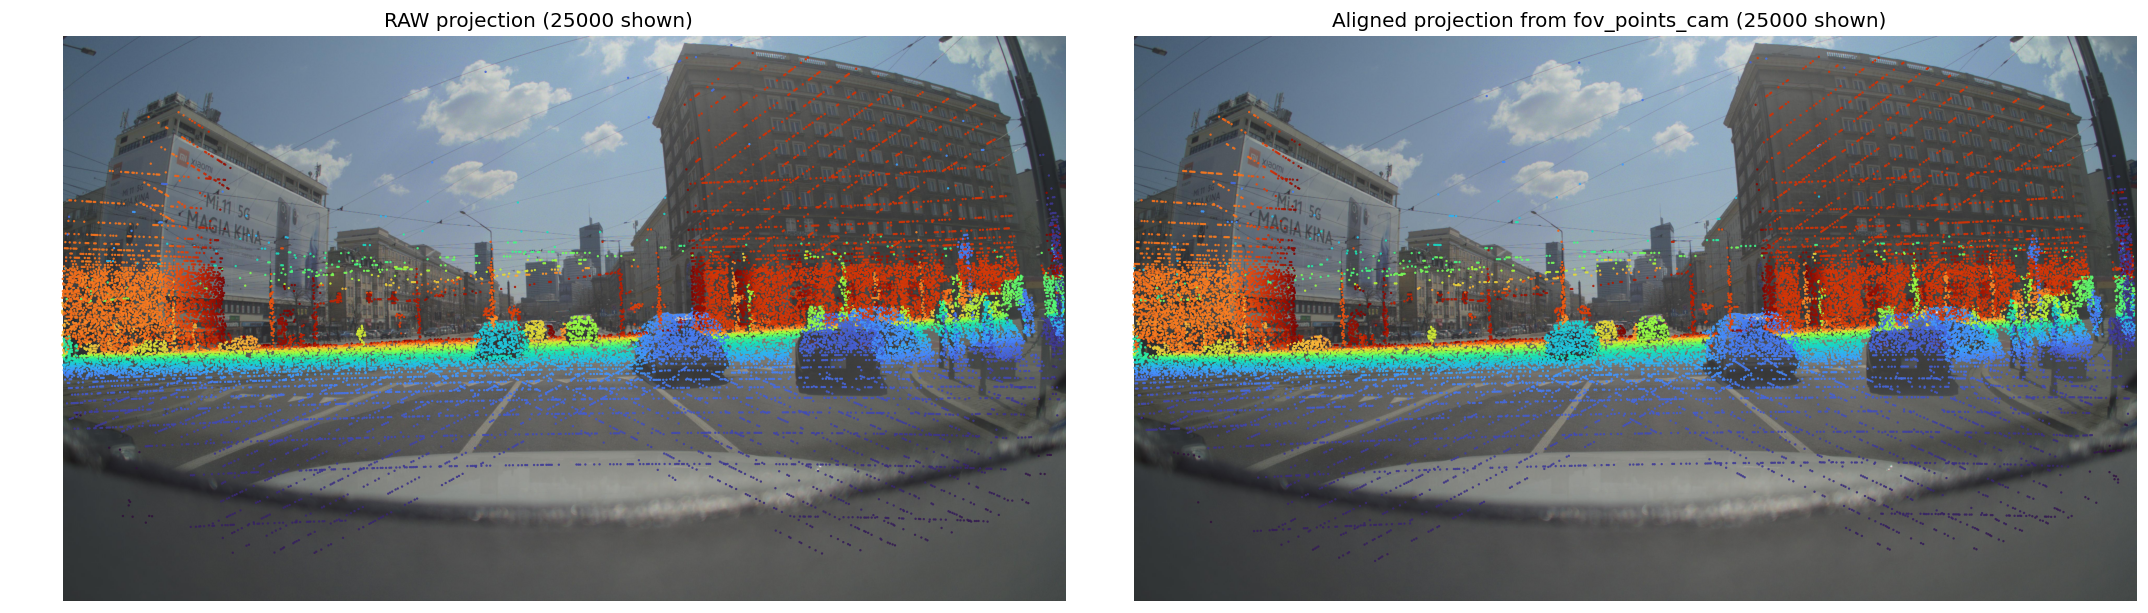

Raw projected total: 80776
Aligned projected total (from fov_points_cam): 81286


In [12]:
# using camera-frame FOV LiDAR points we created above.

from zod.utils.geometry import project_3d_to_2d_kannala

# Raw projection (left panel, unchanged reference) ---
raw_xyd, _ = project_lidar_to_image(raw_lidar, calib, lidar=Lidar.VELODYNE, camera=Camera.FRONT)

#  Aligned projection from camera-frame FOV points ---
# fov_points_cam is already positive-depth + FOV-filtered in camera frame.
xy_aligned = project_3d_to_2d_kannala(
    fov_points_cam,
    calib.cameras[Camera.FRONT].intrinsics[..., :3],
    calib.cameras[Camera.FRONT].distortion,
)
aligned_xyd = np.concatenate([xy_aligned, fov_points_cam[:, 2:3]], axis=1)  # [u,v,depth]

# --- 3) Simple display filtering (for readability only) ---
def _display_subset(xyd, max_points=25000, min_depth=1.5, max_depth=60.0, seed=0):
    keep = (xyd[:, 2] >= min_depth) & (xyd[:, 2] <= max_depth)
    pts = xyd[keep]
    if pts.shape[0] > max_points:
        rng = np.random.default_rng(seed)
        pts = pts[rng.choice(pts.shape[0], size=max_points, replace=False)]
    return pts

raw_pts = _display_subset(raw_xyd, max_points=25000, seed=0)
aln_pts = _display_subset(aligned_xyd, max_points=25000, seed=1)

# --- 4) Plot side-by-side ---
fig, axs = plt.subplots(1, 2, figsize=(18, 7), dpi=120)

for ax, pts, title in [
    (axs[0], raw_pts, f"RAW projection ({raw_pts.shape[0]} shown)"),
    (axs[1], aln_pts, f"Aligned projection from fov_points_cam ({aln_pts.shape[0]} shown)"),
]:
    ax.imshow(front_image)
    if pts.shape[0] > 0:
        ax.scatter(
            pts[:, 0], pts[:, 1],
            c=pts[:, 2],
            s=2.0,
            cmap="turbo",
            alpha=0.9,
            linewidths=0,
        )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Raw projected total:", raw_xyd.shape[0])
print("Aligned projected total (from fov_points_cam):", aligned_xyd.shape[0])